In [33]:
import pandas as pd

URL = "https://raw.githubusercontent.com/4GeeksAcademy/naive-bayes-project-tutorial/main/playstore_reviews.csv"

df = pd.read_csv(URL)

df.head()

,package_name,review,polarity
0,com.facebook.katana,privacy at least put some option appear offli...,0
1,com.facebook.katana,"messenger issues ever since the last update, ...",0
2,com.facebook.katana,profile any time my wife or anybody has more ...,0
3,com.facebook.katana,the new features suck for those of us who don...,0
4,com.facebook.katana,forced reload on uploading pic on replying co...,0


Descripción: Cargamos el conjunto de datos de reseñas de Google Play

In [34]:
print(df.shape)

(891, 3)


In [35]:
print(df.columns)

Index(['package_name', 'review', 'polarity'], dtype='str')


In [36]:
#Eliminación de package_name

df = df.drop("package_name", axis=1)

df.head()

,review,polarity
0,privacy at least put some option appear offli...,0
1,"messenger issues ever since the last update, ...",0
2,profile any time my wife or anybody has more ...,0
3,the new features suck for those of us who don...,0
4,forced reload on uploading pic on replying co...,0


In [37]:
#Limpieza del texto

df["review"] = df["review"].str.strip().str.lower()

df.head()

,review,polarity
0,privacy at least put some option appear offlin...,0
1,"messenger issues ever since the last update, i...",0
2,profile any time my wife or anybody has more t...,0
3,the new features suck for those of us who don'...,0
4,forced reload on uploading pic on replying com...,0


In [38]:
# Separamos x e y
X = df["review"]
y = df["polarity"]

In [ ]:
import sys

print(sys.executable)

In [ ]:
!{sys.executable} -m pip show scikit-learn

In [ ]:
!{sys.executable} -m pip install scikit-learn

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (712,)
X_test: (179,)
y_train: (712,)
y_test: (179,)


In [44]:
from sklearn.feature_extraction.text import CountVectorizer

vec_model = CountVectorizer(stop_words="english")

X_train = vec_model.fit_transform(X_train).toarray()
X_test = vec_model.transform(X_test).toarray()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (712, 3310)
X_test: (179, 3310)


In [45]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

gnb.fit(X_train, y_train)

y_pred_gnb = gnb.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score

accuracy_gnb = accuracy_score(y_test, y_pred_gnb)

print(f"Accuracy GaussianNB: {accuracy_gnb:.4f}")

Accuracy GaussianNB: 0.8045


In [47]:
from sklearn.naive_bayes import MultinomialNB

mnb = MultinomialNB()

mnb.fit(X_train, y_train)

y_pred_mnb = mnb.predict(X_test)

In [48]:
accuracy_mnb = accuracy_score(y_test, y_pred_mnb)

print(f"Accuracy MultinomialNB: {accuracy_mnb:.4f}")

Accuracy MultinomialNB: 0.8156


In [49]:
from sklearn.naive_bayes import BernoulliNB

bnb = BernoulliNB()

bnb.fit(X_train, y_train)

y_pred_bnb = bnb.predict(X_test)

In [50]:
accuracy_bnb = accuracy_score(y_test, y_pred_bnb)

print(f"Accuracy BernoulliNB: {accuracy_bnb:.4f}")

Accuracy BernoulliNB: 0.7709


In [51]:
# Comparamos el accuracy de los tres modelos Naive Bayes

models = ["GaussianNB", "MultinomialNB", "BernoulliNB"]
accuracies = [accuracy_gnb, accuracy_mnb, accuracy_bnb]

for model, accuracy in zip(models, accuracies):
    print(f"{model}: {accuracy:.4f}")

GaussianNB: 0.8045
MultinomialNB: 0.8156
BernoulliNB: 0.7709


In [52]:
# Probamos diferentes valores de alpha

alphas = [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]
accuracies_alpha = []

for alpha in alphas:
    model = MultinomialNB(alpha=alpha)
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    accuracies_alpha.append(accuracy)

print(accuracies_alpha)

[0.8212290502793296, 0.8324022346368715, 0.8268156424581006, 0.8156424581005587, 0.8324022346368715, 0.8268156424581006, 0.7988826815642458]


In [ ]:
import sys

!{sys.executable} -m pip install matplotlib

In [65]:
import matplotlib.pyplot as plt

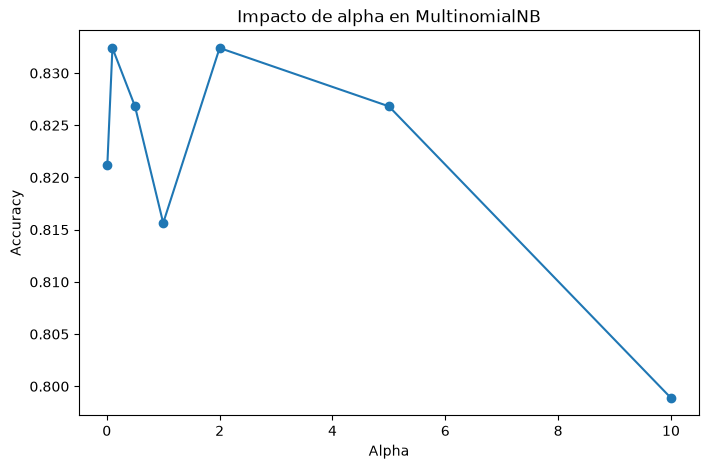

In [66]:
# Gráfico de alpha

plt.figure(figsize=(8, 5))

plt.plot(alphas, accuracies_alpha, marker="o")

plt.xlabel("Alpha")
plt.ylabel("Accuracy")
plt.title("Impacto de alpha en MultinomialNB")

plt.show()

In [67]:
# Entrenamos el modelo optimizado

best_alpha = 0.1

mnb_final = MultinomialNB(alpha=best_alpha)

mnb_final.fit(X_train, y_train)

y_pred_final = mnb_final.predict(X_test)

In [68]:
# Calculamos el accuracy del modelo optimizado

accuracy_final = accuracy_score(y_test, y_pred_final)

print(f"Accuracy MultinomialNB optimizado: {accuracy_final:.4f}")

Accuracy MultinomialNB optimizado: 0.8324


In [69]:
from sklearn.ensemble import RandomForestClassifier

rf_text = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_text.fit(X_train, y_train)

y_pred_rf = rf_text.predict(X_test)

In [70]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy Random Forest: {accuracy_rf:.4f}")

Accuracy Random Forest: 0.7989


In [71]:
# Probamos diferentes cantidades de árboles

n_estimators_values = [10, 50, 100, 150, 200]
accuracies_rf = []

for n in n_estimators_values:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    accuracies_rf.append(accuracy)

print(accuracies_rf)

[0.8100558659217877, 0.8212290502793296, 0.7988826815642458, 0.8100558659217877, 0.8156424581005587]


In [74]:
# Comparamos el mejor Random Forest con el mejor Naive Bayes

best_rf_accuracy = max(accuracies_rf)

print(f"Mejor Random Forest: {best_rf_accuracy:.4f}")
print(f"Mejor MultinomialNB: {accuracy_final:.4f}")

Mejor Random Forest: 0.8212
Mejor MultinomialNB: 0.8324


In [75]:
import joblib

joblib.dump(best_model, "playstore_naive_bayes.pkl")

['playstore_naive_bayes.pkl']

In [76]:
import os

print(os.path.exists("playstore_naive_bayes.pkl"))

True


In [77]:
joblib.dump(vec_model, "playstore_count_vectorizer.pkl")

['playstore_count_vectorizer.pkl']

In [78]:
print(os.path.exists("playstore_count_vectorizer.pkl"))

True


In [79]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

In [80]:
accuracy_log = accuracy_score(y_test, y_pred_log)

print(f"Accuracy Regresión Logística: {accuracy_log:.4f}")

Accuracy Regresión Logística: 0.8324


In [81]:
# Comparamos los mejores modelos

print(f"MultinomialNB optimizado: {accuracy_final:.4f}")
print(f"Random Forest optimizado: {best_rf_accuracy:.4f}")
print(f"Regresión Logística: {accuracy_log:.4f}")

MultinomialNB optimizado: 0.8324
Random Forest optimizado: 0.8212
Regresión Logística: 0.8324


Descripción:
El mejor resultado obtenido es un empate entre MultinomialNB optimizado y Regresión Logística, ambos con un accuracy de 0.8324. Random Forest obtiene un resultado inferior, con 0.8212.

Comparación de las predicciones

Descripción:
Analizamos el comportamiento de los modelos mediante precision, recall y f1-score para las clases 0 (reseña negativa) y 1 (reseña positiva).

In [82]:
from sklearn.metrics import classification_report

print("MultinomialNB optimizado:")
print(classification_report(y_test, y_pred_final))

MultinomialNB optimizado:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       126
           1       0.74      0.66      0.70        53

    accuracy                           0.83       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.83      0.83      0.83       179



In [83]:
print("Regresión Logística:")
print(classification_report(y_test, y_pred_log))

Regresión Logística:
              precision    recall  f1-score   support

           0       0.91      0.84      0.88       126
           1       0.68      0.81      0.74        53

    accuracy                           0.83       179
   macro avg       0.80      0.83      0.81       179
weighted avg       0.85      0.83      0.84       179



Conclusión

En este proyecto hemos desarrollado un sistema de clasificación de sentimientos
para reseñas de Google Play utilizando diferentes modelos de Machine Learning.

Primero comparamos las tres implementaciones de Naive Bayes:

 GaussianNB: 0.8045
 MultinomialNB: 0.8156
BernoulliNB: 0.7709